Downloading Respective Models:

In [1]:
import ollama

print("Downloading llama3.2... Please wait.")
ollama.pull('llama3.2')
print("Success! Model is ready to use.")

print("Downloading llava... Please wait.")
ollama.pull('llava')
print("Success! Model is ready to use.")


Success! Model is ready to use.
Success! Model is ready to use.


Verify the Installation of Libraries:

In [3]:
import langchain
import langchain_ollama
import langchain_core
import langgraph
from importlib.metadata import version

print("LangChain version      :", langchain.__version__)
print("LangChain-Ollama version:", langchain_ollama.__version__)
print("LangChain-Core version  :", langchain_core.__version__)
print("LangGraph version       :", version("langgraph"))

LangChain version      : 1.3.1
LangChain-Ollama version: 1.1.0
LangChain-Core version  : 1.4.0
LangGraph version       : 1.2.0


Verify is Models are running:

In [4]:
import requests

response = requests.get("http://localhost:11434/api/tags")
models = response.json()

print("Ollama is running ✅")
print("\nAvailable models:")
for model in models["models"]:
    print(f"  - {model['name']}")

Ollama is running ✅

Available models:
  - llava:latest
  - llama3.2:latest
  - qwen2.5:3b
  - qwen3.5:2b
  - gemma3:270m


Quick Sanity Test:

In [5]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.2",
    base_url="http://localhost:11434"
)

response = llm.invoke("Say hello in one sentence.")
print(response.content)

Hello!


Defining Agent State:

In [6]:
from typing import TypedDict

class AgentState(TypedDict):
    image_path: str        # input — path to the food image
    nutrition_data: str    # output of Agent 1 (Nutrition Analyst)
    recipe: str            # output of Agent 2 (Recipe Creator)
    meal_advice: str       # output of Agent 3 (Meal Advisor)

In [7]:
# Simulate what the initial state looks like when graph starts
initial_state: AgentState = {
    "image_path": "sample_food.jpg",
    "nutrition_data": "",
    "recipe": "",
    "meal_advice": ""
}

print("State keys   :", list(initial_state.keys()))
print("image_path   :", initial_state["image_path"])
print("nutrition_data:", initial_state["nutrition_data"])
print("recipe       :", initial_state["recipe"])
print("meal_advice  :", initial_state["meal_advice"])

State keys   : ['image_path', 'nutrition_data', 'recipe', 'meal_advice']
image_path   : sample_food.jpg
nutrition_data: 
recipe       : 
meal_advice  : 


Importing Vision Tool:

In [8]:
import base64
import requests
from langchain_core.tools import tool

Building the main function using tool decorator

In [9]:
@tool
def analyze_food_image(image_path: str) -> str:
    """
    Analyzes a food image using llava vision model.
    Extracts food items, estimates calories and macronutrients.
    
    Args:
        image_path: local file path to the food image
    
    Returns:
        str: nutrition analysis text from llava
    """
    # Step 1 — read image and convert to base64
    with open(image_path, "rb") as f:
        image_data = base64.b64encode(f.read()).decode("utf-8")
    
    # Step 2 — build prompt
    prompt = """
    Analyze this food image carefully and provide:
    1. List of all food items visible
    2. Estimated calories for each item
    3. Macronutrients (protein, carbs, fats) for each item
    4. Total calories for the entire meal
    Be specific and structured in your response.
    """
    
    # Step 3 — call Ollama vision API
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llava",
            "prompt": prompt,
            "images": [image_data],
            "stream": False
        }
    )
    
    # Step 4 — extract and return response
    return response.json()["response"]

In [10]:
image_path = r"C:\Users\SANDEEP S\Desktop\sample_food.png"

# Verify the file exists
import os
if os.path.exists(image_path):
    print("Image found ✅ →", image_path)
else:
    print("Image NOT found ❌ — check the path")

Image found ✅ → C:\Users\SANDEEP S\Desktop\sample_food.png


In [11]:
result = analyze_food_image.invoke({"image_path": image_path})
print(result)

 1. List of all food items visible:
   - Hamburger with meat patty, cheese, lettuce, tomato, onion, and condiments (ketchup and mustard)
   - French fries
   - A side salad consisting of greens and possibly other vegetables

2. Estimated calories for each item:
   - Hamburger: 500-800 calories (based on a standard patty, bun, and toppings)
   - Fries: 300-450 calories (approximately 1 cup of fries can contain around 400 calories or more)
   - Salad: 50-200 calories (depending on the size and ingredients of the salad)

3. Macronutrients for each item:
   - Hamburger: Approximately 18g of protein (from the meat patty), 40g of carbohydrates (from the bun), and 25-40g of fat (depending on cooking method, cheese type, and condiments used)
   - Fries: Approximately 30g of carbohydrates and 15g of fat (assuming a typical fried potato product)
   - Salad: High in carbohydrates (from the greens or other vegetables), moderate in protein (depending on whether any protein source like chicken, tuna

Now to Create LLM configurations and AgentNodes:

In [12]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.2",
    base_url="http://localhost:11434",
    temperature=0.7
)

print("LLM ready ✅")

LLM ready ✅


In [13]:
from langchain_core.messages import HumanMessage

def nutrition_analyst_node(state: AgentState) -> dict:
    """
    Agent 1 — Reads image_path from state.
    Calls vision tool → writes nutrition_data back to state.
    """
    print("🔍 Agent 1: Nutrition Analyst running...")
    
    # Call the vision tool we built in Step 3
    nutrition_data = analyze_food_image.invoke({
        "image_path": state["image_path"]
    })
    
    print("✅ Agent 1 done")
    return {"nutrition_data": nutrition_data}

In [14]:
def recipe_creator_node(state: AgentState) -> dict:
    """
    Agent 2 — Reads nutrition_data from state.
    Generates a healthy recipe → writes recipe back to state.
    """
    print("👨‍🍳 Agent 2: Recipe Creator running...")
    
    prompt = f"""
    Based on the following nutrition analysis of a meal:
    
    {state["nutrition_data"]}
    
    Create a healthier alternative recipe that:
    1. Uses similar ingredients but with healthier substitutions
    2. Reduces calories by at least 20%
    3. Maintains the same satisfying flavors
    4. Includes exact ingredients with measurements
    5. Includes step by step cooking instructions
    
    Format your response clearly with sections:
    - Recipe Name
    - Ingredients
    - Instructions
    - Estimated Nutrition
    """
    
    response = llm.invoke([HumanMessage(content=prompt)])
    
    print("✅ Agent 2 done")
    return {"recipe": response.content}

In [15]:
def meal_advisor_node(state: AgentState) -> dict:
    """
    Agent 3 — Reads nutrition_data + recipe from state.
    Generates personalized meal advice → writes meal_advice to state.
    """
    print("🥗 Agent 3: Meal Advisor running...")
    
    prompt = f"""
    You are a personal nutrition coach. Based on the following:
    
    ORIGINAL MEAL NUTRITION ANALYSIS:
    {state["nutrition_data"]}
    
    HEALTHIER RECIPE SUGGESTION:
    {state["recipe"]}
    
    Provide personalized meal advice including:
    1. Key nutritional insights about the original meal
    2. Why the healthier recipe is better
    3. 3 daily meal tips for a balanced diet
    4. Best time of day to eat this type of meal
    5. One simple habit to improve eating patterns
    
    Keep your response practical and motivating.
    """
    
    response = llm.invoke([HumanMessage(content=prompt)])
    
    print("✅ Agent 3 done")
    return {"meal_advice": response.content}

In [16]:
# Build a mock state to test nodes independently
mock_state: AgentState = {
    "image_path": image_path,
    "nutrition_data": "",
    "recipe": "",
    "meal_advice": ""
}

# Test Node 1 only
result_node1 = nutrition_analyst_node(mock_state)
print("\n--- Node 1 Output ---")
print(result_node1["nutrition_data"][:300], "...")  # print first 300 chars

🔍 Agent 1: Nutrition Analyst running...
✅ Agent 1 done

--- Node 1 Output ---
 1. Food items visible:
   - Hamburger with beef patty, cheese, lettuce, tomato, onion, and a sesame seed bun.
   - French fries.

2. Estimated calories for each item (based on average values):
   - Hamburger: 650-850 calories
   - Fries: 200-300 calories

3. Macronutrients for each item:
   - Hambu ...


Graph Assembly:

In [17]:
from langgraph.graph import StateGraph, START, END

In [18]:
# Step 1 — initialize graph with our AgentState schema
builder = StateGraph(AgentState)

# Step 2 — register all nodes
builder.add_node("nutrition_analyst", nutrition_analyst_node)
builder.add_node("recipe_creator", recipe_creator_node)
builder.add_node("meal_advisor", meal_advisor_node)

# Step 3 — define edges (flow between nodes)
builder.add_edge(START, "nutrition_analyst")
builder.add_edge("nutrition_analyst", "recipe_creator")
builder.add_edge("recipe_creator", "meal_advisor")
builder.add_edge("meal_advisor", END)

# Step 4 — compile the graph
graph = builder.compile()

print("Graph compiled successfully ✅")

Graph compiled successfully ✅


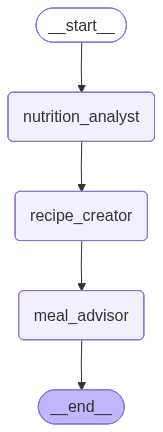

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
# Final state to kick off the graph
initial_state: AgentState = {
    "image_path": image_path,
    "nutrition_data": "",
    "recipe": "",
    "meal_advice": ""
}

# Invoke the graph
final_state = graph.invoke(initial_state)

🔍 Agent 1: Nutrition Analyst running...
✅ Agent 1 done
👨‍🍳 Agent 2: Recipe Creator running...
✅ Agent 2 done
🥗 Agent 3: Meal Advisor running...
✅ Agent 3 done


In [21]:
print("=" * 60)
print("🔍 NUTRITION ANALYSIS")
print("=" * 60)
print(final_state["nutrition_data"])

print("\n" + "=" * 60)
print("👨‍🍳 HEALTHY RECIPE SUGGESTION")
print("=" * 60)
print(final_state["recipe"])

print("\n" + "=" * 60)
print("🥗 PERSONALIZED MEAL ADVICE")
print("=" * 60)
print(final_state["meal_advice"])

🔍 NUTRITION ANALYSIS
 1. The image depicts a burger and fries as the main food items visible. There are no additional food items present in the image.

2. Estimated Calories:
   - Burger: A standard beef patty can range between 280 to 540 calories depending on the specifics of the burger. A single cheeseburger typically contains around 450-750 calories.
   - Fries: Potato fries can range from 150-350 calories per serving, and since no portion size is visible, an estimation based on a standard serving of fries would be around 250-350 calories.

3. Macronutrients (Protein, Carbs, Fats):
   - Burger: A typical beef patty contains about 15-25 grams of protein, 40-60 grams of carbohydrates, and 9-18 grams of fat. The bun and additional toppings will add more carbohydrates and some fats.
   - Fries: Potato fries are high in carbohydrates (potatoes) and typically contain small amounts of protein and fat. A medium serving of fries might have around 25-30 grams of carbohydrates, 1-3 grams of pr